# SPX

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

from scipy import stats
from scipy.optimize import minimize

## Question 1

### 1.1 Load & clean the CSV (Barchart format)

In [2]:
file_path = r"D:\MG\! CUHKSZ\~！大三 下\FMA 4200\Homework\HW 1\spx-options-exp-2025-03-13-weekly.csv"

raw = pd.read_csv(file_path)

# Standardize column names
raw.columns = raw.columns.str.strip()

# Drop footer-like rows (e.g., "Downloaded from ...")
raw = raw[raw["Strike"].astype(str).str.contains(r"\d", na=False)].copy()

# Convert numeric columns that may contain commas or percent signs
def to_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s = s.replace(",", "")
    s = s.replace("%", "")
    if s in ["unch", "N/A", "nan", "None", ""]:
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

num_cols = ["Strike","Bid","Mid","Ask","Last","Volume","Open Int","OI Chg","Delta","IV","Moneyness"]
for c in num_cols:
    raw[c] = raw[c].apply(to_float)

raw["Type"] = raw["Type"].astype(str).str.strip().str.title()

raw.head()

,Strike,Moneyness,Bid,Mid,Ask,Last,Change,%Chg,Volume,Open Int,OI Chg,Delta,IV,Type,Time
0,2400.0,60.75,3697.8,3713.85,3729.9,0.0,unch,unch,0.0,0.0,NaN,0.99285,151.28,Call,NaN
1,2600.0,57.48,3498.5,3514.55,3530.6,0.0,unch,unch,0.0,0.0,NaN,0.99218,139.35,Call,NaN
2,2800.0,54.21,3299.2,3315.25,3331.3,0.0,unch,unch,0.0,0.0,NaN,0.99146,128.30,Call,NaN
3,3000.0,50.94,3099.9,3116.00,3132.1,0.0,unch,unch,0.0,0.0,NaN,0.99057,118.24,Call,NaN
4,3200.0,47.67,2900.6,2916.70,2932.8,0.0,unch,unch,0.0,0.0,NaN,0.98969,108.57,Call,NaN


### 1.2 Set dates, maturity, and risk-free rate (r)

Valuation date: **2025-02-13**
Expiry: **2025-03-13**
So $T = 28/365$.

For $r$, use a short bill rate (annualized). The Treasury daily bill table for **02/13/2025** provides bill yields; for a ~1-month horizon, using the **4-week investment yield** is a reasonable classroom choice.

In [3]:
val_date = pd.Timestamp("2025-02-13")
exp_date = pd.Timestamp("2025-03-13")
T = (exp_date - val_date).days / 365.0

# Approx short rate (annualized, continuously compounded)
# You can replace this number with the exact 4-week "investment yield" you read from Treasury's table for 02/13/2025.
r_simple = 0.0432  # ~4.32% annualized (example from Treasury bill table vicinity)
r = np.log(1 + r_simple)  # convert to continuous compounding (optional)

T, r

(0.07671232876712329, 0.042292912190251365)

### 1.3 Infer the SPX spot level (S_0) from the “Moneyness” column (your file’s convention)

From the sample, **Moneyness ≈ (S − K) / S** (e.g., for K=6050 with 1.06% gives S≈6116), so:

$$
m = \frac{S-K}{S}\ \Rightarrow\ S = \frac{K}{1-m}.
$$

In [4]:
# Moneyness is in percent units already converted to float; convert to decimal
m = raw["Moneyness"] / 100.0
S_implied = raw["Strike"] / (1 - m)

S0 = np.nanmedian(S_implied)
S0

6114.961271911945

### 1.4 Filtering (liquidity + sanity checks)

Typical “lecture” filters (also consistent with index-option constructions like VIX):

* keep **Bid > 0** and **Ask > 0** (and thus meaningful Mid)
* keep **IV > 0** (and drop obvious garbage like 0.00%)
* keep valid Type ∈ {Call, Put}
* optional: drop absurd spreads / missing deltas

In [5]:
df = raw.copy()

# Core liquidity/sanity filters
df = df[df["Type"].isin(["Call","Put"])]
df = df[(df["Bid"] > 0) & (df["Ask"] > 0)]
df = df[df["Mid"].notna() & (df["Mid"] > 0)]
df = df[df["IV"].notna() & (df["IV"] > 0)]

# Optional: spread filter (relative)
df["rel_spread"] = (df["Ask"] - df["Bid"]) / df["Mid"]
df = df[df["rel_spread"] < 0.25]  # tune if your lecture notes specify a different cutoff

df.shape, df.head()

((160, 16),
    Strike  Moneyness     Bid      Mid     Ask  Last Change  %Chg  Volume  \
 0  2400.0      60.75  3697.8  3713.85  3729.9   0.0   unch  unch     0.0   
 1  2600.0      57.48  3498.5  3514.55  3530.6   0.0   unch  unch     0.0   
 2  2800.0      54.21  3299.2  3315.25  3331.3   0.0   unch  unch     0.0   
 3  3000.0      50.94  3099.9  3116.00  3132.1   0.0   unch  unch     0.0   
 4  3200.0      47.67  2900.6  2916.70  2932.8   0.0   unch  unch     0.0   
 
    Open Int  OI Chg    Delta      IV  Type Time  rel_spread  
 0       0.0     NaN  0.99285  151.28  Call  NaN    0.008643  
 1       0.0     NaN  0.99218  139.35  Call  NaN    0.009133  
 2       0.0     NaN  0.99146  128.30  Call  NaN    0.009683  
 3       0.0     NaN  0.99057  118.24  Call  NaN    0.010334  
 4       0.0     NaN  0.98969  108.57  Call  NaN    0.011040  )

### 1.5 Determine the “center” strike (K_0) (ATM-ish) and keep only OTM options

A standard approach:

* pick $K_0$ as the strike closest to $S_0$ (or forward $F$ if you compute it from put-call parity).
* keep **OTM puts**: $K < K_0$
* keep **OTM calls**: $K > K_0$
* for the “ATM point”, either include both or take an average; here we keep the closest strike as “ATM anchor”.

(Using OTM-only is exactly the convention you’ll see in widely-used SPX option methodologies like VIX.)

In [6]:
# Choose K0 = strike closest to S0
strikes = np.sort(df["Strike"].unique())
K0 = strikes[np.argmin(np.abs(strikes - S0))]

K0, S0

(6110.0, 6114.961271911945)

In [7]:
# Keep OTM set
otm_puts  = df[(df["Type"]=="Put")  & (df["Strike"] <= K0)]
otm_calls = df[(df["Type"]=="Call") & (df["Strike"] >= K0)]

otm = pd.concat([otm_puts, otm_calls], ignore_index=True)

# For each strike, we want exactly one IV quote:
# - below K0: use put
# - above K0: use call
# - at K0: if both exist, average their IVs
def pick_iv(group):
    K = group["Strike"].iloc[0]
    if K < K0:
        g = group[group["Type"]=="Put"]
        return g.iloc[0]
    elif K > K0:
        g = group[group["Type"]=="Call"]
        return g.iloc[0]
    else:
        # ATM: average if both types exist
        if set(group["Type"]) == {"Call","Put"}:
            row = group.iloc[0].copy()
            row["IV"] = group["IV"].mean()
            row["Type"] = "ATM(avg)"
            return row
        else:
            return group.iloc[0]

curve_df = (otm.sort_values(["Strike","Type"])
              .groupby("Strike", as_index=False)
              .apply(lambda g: pick_iv(g))
              .reset_index(drop=True))

curve_df["k_over_s"] = curve_df["Strike"] / S0
curve_df["iv_dec"] = curve_df["IV"] / 100.0  # convert % to decimal

curve_df.head(), curve_df.shape

C:\Users\19927\AppData\Local\Temp\ipykernel_47532\2564230862.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pick_iv(g))


(   Strike  Moneyness   Bid   Mid   Ask  Last Change     %Chg  Volume  \
 0  4400.0     -28.05  1.25  1.43  1.60  1.50  -0.30  -16.67%    49.0   
 1  4500.0     -26.41  1.45  1.60  1.75  1.65  +1.65     unch     1.0   
 2  4600.0     -24.78  1.65  1.83  2.00  2.72   unch     unch     0.0   
 3  4700.0     -23.14  1.90  2.05  2.20  2.75   unch     unch     0.0   
 4  4800.0     -21.51  2.15  2.33  2.50  2.30  +2.30     unch    39.0   
 
    Open Int  OI Chg    Delta     IV Type      Time  rel_spread  k_over_s  \
 0       5.0     1.0 -0.00550  48.45  Put  02/13/25    0.244755  0.719547   
 1       0.0     NaN -0.00630  46.00  Put  02/13/25    0.187500  0.735900   
 2      12.0     NaN -0.00726  43.59  Put  02/07/25    0.191257  0.752253   
 3      16.0     NaN -0.00849  41.26  Put  02/11/25    0.146341  0.768607   
 4     212.0     NaN -0.00995  38.93  Put  02/13/25    0.150215  0.784960   
 
    iv_dec  
 0  0.4845  
 1  0.4600  
 2  0.4359  
 3  0.4126  
 4  0.3893  ,
 (72, 18))

### 1.6 Plot the implied volatility curve (raw + smoothed)

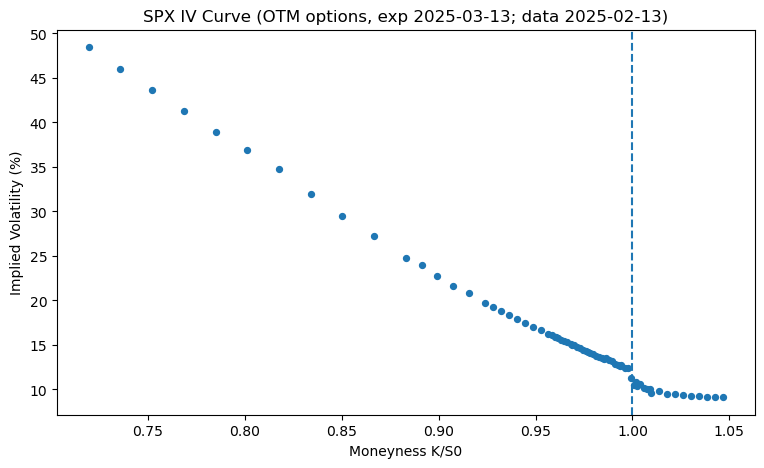

In [8]:
x = curve_df["k_over_s"].values
y = curve_df["IV"].values  # keep in percent for readability

plt.figure(figsize=(9,5))
plt.scatter(x, y, s=18)
plt.axvline(1.0, linestyle="--")
plt.xlabel("Moneyness K/S0")
plt.ylabel("Implied Volatility (%)")
plt.title("SPX IV Curve (OTM options, exp 2025-03-13; data 2025-02-13)")
plt.show()

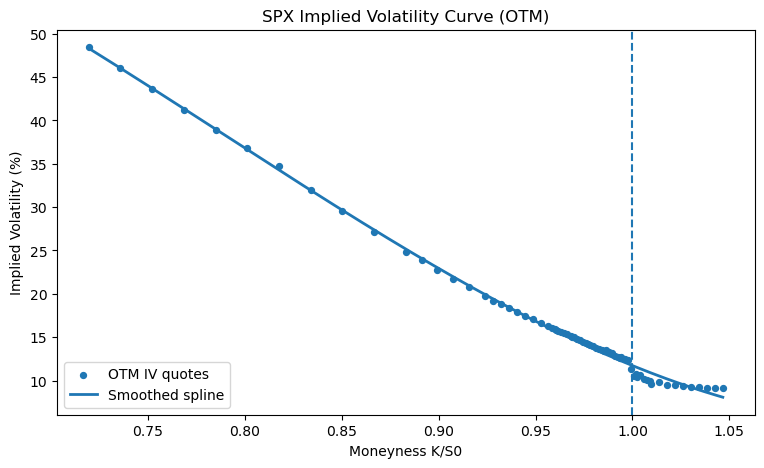

In [9]:
# Sort for spline
ord_idx = np.argsort(x)
x_s = x[ord_idx]
y_s = y[ord_idx]

# Smoothing spline: s controls smoothness; tune as needed
spl = UnivariateSpline(x_s, y_s, s=len(x_s)*0.5)

x_grid = np.linspace(x_s.min(), x_s.max(), 300)
y_grid = spl(x_grid)

plt.figure(figsize=(9,5))
plt.scatter(x_s, y_s, s=18, label="OTM IV quotes")
plt.plot(x_grid, y_grid, linewidth=2, label="Smoothed spline")
plt.axvline(1.0, linestyle="--")
plt.xlabel("Moneyness K/S0")
plt.ylabel("Implied Volatility (%)")
plt.title("SPX Implied Volatility Curve (OTM)")
plt.legend()
plt.show()

## Question 2

### 2.1 Helper: compute VIX single-term variance from one expiration

This follows Cboe’s “single term” variance formula
$$
\sigma^2=\frac{2}{T}\sum_i\frac{\Delta K_i}{K_i^2}e^{rT}Q(K_i)-\frac{1}{T}\left(\frac{F}{K_0}-1\right)^2,
$$
with $Q(K)$ the **mid-quote** of the OTM option at strike $K$, and $K_0$ the first strike **at or below** forward $F$.

In [10]:
def vix_single_term_variance(df_term: pd.DataFrame, r: float, T: float):
    """
    Compute Cboe-style single-term variance sigma^2 from one expiration.
    df_term must contain columns: Strike, Type, Bid, Ask, Mid (or Bid/Ask to build Mid).
    We assume df_term already filtered for reasonable quotes (Bid>0, Ask>0, etc.).
    Returns: (sigma2, F, K0, table_used)
    """
    tmp = df_term.copy()

    # Ensure Mid exists
    if "Mid" not in tmp.columns or tmp["Mid"].isna().all():
        tmp["Mid"] = 0.5 * (tmp["Bid"] + tmp["Ask"])

    tmp = tmp[tmp["Type"].isin(["Call", "Put"])].copy()
    tmp = tmp[(tmp["Bid"] > 0) & (tmp["Ask"] > 0) & (tmp["Mid"] > 0)].copy()

    # Pivot to have call/put at same strike for forward calc
    piv = tmp.pivot_table(index="Strike", columns="Type", values="Mid", aggfunc="first")
    piv = piv.dropna(subset=["Call", "Put"]).copy()

    # Pick strike where |C - P| minimized (Cboe step used in practice to infer forward)
    piv["abs_cp"] = (piv["Call"] - piv["Put"]).abs()
    K_star = float(piv["abs_cp"].idxmin())
    C_star = float(piv.loc[K_star, "Call"])
    P_star = float(piv.loc[K_star, "Put"])

    # Forward estimate: F = K + e^{rT}(C - P)
    F = K_star + np.exp(r * T) * (C_star - P_star)

    # K0 = first strike <= F
    strikes_all = np.sort(tmp["Strike"].unique())
    K0 = strikes_all[strikes_all <= F].max()

    # Build Q(K): OTM puts for K < K0, OTM calls for K > K0, and average at K0 if both exist
    piv_all = tmp.pivot_table(index="Strike", columns="Type", values=["Mid", "Bid"], aggfunc="first")
    # Convenience accessors:
    def get_val(K, field, opt_type):
        try:
            return float(piv_all.loc[K, (field, opt_type)])
        except:
            return np.nan

    strikes = np.sort(tmp["Strike"].unique())

    used_rows = []
    for K in strikes:
        if K < K0:
            # Put
            q = get_val(K, "Mid", "Put")
            b = get_val(K, "Bid", "Put")
            opt = "Put"
        elif K > K0:
            # Call
            q = get_val(K, "Mid", "Call")
            b = get_val(K, "Bid", "Call")
            opt = "Call"
        else:
            # K == K0: average call/put
            q_call = get_val(K, "Mid", "Call")
            q_put  = get_val(K, "Mid", "Put")
            b_call = get_val(K, "Bid", "Call")
            b_put  = get_val(K, "Bid", "Put")
            if np.isfinite(q_call) and np.isfinite(q_put):
                q = 0.5 * (q_call + q_put)
                b = np.nanmin([b_call, b_put])  # just for diagnostics
                opt = "Both(avg)"
            elif np.isfinite(q_put):
                q, b, opt = q_put, b_put, "Put"
            else:
                q, b, opt = q_call, b_call, "Call"

        if not np.isfinite(q) or q <= 0:
            continue

        used_rows.append((K, opt, q, b))

    used = pd.DataFrame(used_rows, columns=["Strike", "TypeUsed", "Q", "BidUsed"])
    used = used.sort_values("Strike").reset_index(drop=True)

    # Compute ΔK_i
    K_arr = used["Strike"].values
    dK = np.empty_like(K_arr)

    if len(K_arr) < 3:
        raise ValueError("Not enough strikes after filtering to compute ΔK properly.")

    dK[0]  = K_arr[1] - K_arr[0]
    dK[-1] = K_arr[-1] - K_arr[-2]
    dK[1:-1] = 0.5 * (K_arr[2:] - K_arr[:-2])

    used["dK"] = dK
    used["term"] = used["dK"] / (used["Strike"]**2) * np.exp(r * T) * used["Q"]

    # Cboe single-term variance
    sigma2 = (2.0 / T) * used["term"].sum() - (1.0 / T) * ((F / K0) - 1.0)**2

    return float(sigma2), float(F), float(K0), used

### 2.2 Compute your “VIX-like” 30-day estimate from the 28-day expiration

Official VIX uses **two terms** bracketing 30 days and applies the **constant maturity term** weighting in **total variance**.
Here you only have one term (exp 2025-03-13 → about 28 days). A standard approximation is:

* compute **single-term** $\sigma^2$ at $T$
* convert to **30-day constant maturity** by scaling total variance linearly: $$\text{Var}_{30} \approx \frac{T\sigma^2}{T_{30}},\quad T_{30}=\frac{30}{365}$$
* then $\text{VIX}_{30} \approx 100\sqrt{\text{Var}_{30}}$

This is consistent with the idea that VIX interpolation is done in **total variance** (linear in time).

In [11]:
# Use your existing filtered df (already Bid/Ask/Mid sanity filtered)
sigma2_T, F_hat, K0_vix, used_tbl = vix_single_term_variance(df, r=r, T=T)

T30 = 30.0 / 365.0
var30 = (T * sigma2_T) / T30
vix_est = 100.0 * np.sqrt(var30)

sigma2_T, F_hat, K0_vix, vix_est

(0.019940351450342966, 6123.244313101113, 6120.0, 13.642211949308944)

### 2.3 Compare to the reported VIX = 15.10 on 2025-02-13

FRED’s VIX close series shows **15.10** for **2025-02-13**.

In [12]:
vix_reported = 15.10
diff = vix_est - vix_reported
pct_diff = diff / vix_reported * 100

print(f"Your VIX-like estimate (30d scaled from 28d term): {vix_est:.4f}")
print(f"Reported VIX (Cboe, 2025-02-13):               {vix_reported:.2f}")
print(f"Difference:                                    {diff:.4f}  ({pct_diff:.2f}%)")

Your VIX-like estimate (30d scaled from 28d term): 13.6422
Reported VIX (Cboe, 2025-02-13):               15.10
Difference:                                    -1.4578  (-9.65%)


In [13]:
print(f"T (years)          = {T:.6f}  ({(exp_date - val_date).days} days)")
print(f"r (cc)             = {r:.6f}")
print(f"Forward F_hat      = {F_hat:.4f}")
print(f"K0 (<=F)           = {K0_vix:.2f}")
print(f"# strikes used     = {len(used_tbl)}")

used_tbl.head(10), used_tbl.tail(10)

T (years)          = 0.076712  (28 days)
r (cc)             = 0.042293
Forward F_hat      = 6123.2443
K0 (<=F)           = 6120.00
# strikes used     = 72


(   Strike TypeUsed     Q  BidUsed     dK      term
 0  4400.0      Put  1.43     1.25  100.0  0.000007
 1  4500.0      Put  1.60     1.45  100.0  0.000008
 2  4600.0      Put  1.83     1.65  100.0  0.000009
 3  4700.0      Put  2.05     1.90  100.0  0.000009
 4  4800.0      Put  2.33     2.15  100.0  0.000010
 5  4900.0      Put  2.63     2.45  100.0  0.000011
 6  5000.0      Put  3.00     2.80  100.0  0.000012
 7  5100.0      Put  3.30     3.10  100.0  0.000013
 8  5200.0      Put  3.75     3.50  100.0  0.000014
 9  5300.0      Put  4.25     4.00  100.0  0.000015,
     Strike TypeUsed      Q  BidUsed    dK      term
 62  6175.0     Call  49.45     47.2  15.0  0.000020
 63  6200.0     Call  38.65     36.6  25.0  0.000025
 64  6225.0     Call  29.60     27.8  25.0  0.000019
 65  6250.0     Call  23.20     22.6  25.0  0.000015
 66  6275.0     Call  17.20     16.6  25.0  0.000011
 67  6300.0     Call  12.50     12.0  25.0  0.000008
 68  6325.0     Call   9.00      8.6  25.0  0.000006
 69

## Question 3

In [14]:
assert "Strike" in used_tbl.columns and "Q" in used_tbl.columns and "dK" in used_tbl.columns, \
    "used_tbl must have columns: Strike, Q, dK"

used = used_tbl.copy().sort_values("Strike").reset_index(drop=True)
used = used[(used["Q"].notna()) & (used["Q"] > 0) & (used["dK"].notna()) & (used["dK"] > 0)].copy()

growth = np.exp(r * T)

K = used["Strike"].to_numpy(dtype=float)
Q = used["Q"].to_numpy(dtype=float)
dK = used["dK"].to_numpy(dtype=float)

# Choose an anchor strike K0_anchor close to forward F_hat (discrete)
F = float(F_hat)
K0_anchor = float(K[np.argmin(np.abs(K - F))])

### 3.1 Define phi(s) and its first/second derivatives for log-return moments

In [15]:
def L(s: np.ndarray, S0: float) -> np.ndarray:
    return np.log(s / S0)

# phi1 = X
def phi1(s, S0):
    return L(s, S0)

def phi1_p(s, S0):
    return 1.0 / s

def phi1_pp(s, S0):
    return -1.0 / (s**2)

# phi2 = X^2
def phi2(s, S0):
    x = L(s, S0)
    return x**2

def phi2_p(s, S0):
    x = L(s, S0)
    return 2.0 * x / s

def phi2_pp(s, S0):
    x = L(s, S0)
    # d^2/ds^2 [ (ln(s/S0))^2 ] = 2*(1 - ln(s/S0))/s^2
    return 2.0 * (1.0 - x) / (s**2)

# phi3 = X^3
def phi3(s, S0):
    x = L(s, S0)
    return x**3

def phi3_p(s, S0):
    x = L(s, S0)
    return 3.0 * (x**2) / s

def phi3_pp(s, S0):
    x = L(s, S0)
    # d^2/ds^2 [ (ln(s/S0))^3 ] = (3/s^2) * (2 ln(s/S0) - (ln(s/S0))^2)
    return (3.0 / (s**2)) * (2.0 * x - x**2)

# phi4 = X^4
def phi4(s, S0):
    x = L(s, S0)
    return x**4

def phi4_p(s, S0):
    x = L(s, S0)
    return 4.0 * (x**3) / s

def phi4_pp(s, S0):
    x = L(s, S0)
    # d^2/ds^2 [ (ln(s/S0))^4 ] = (4/s^2) * (3 x^2 - x^3)
    return (4.0 / (s**2)) * (3.0 * x**2 - x**3)

### 3.2 Generic model-free expectation from OTM strip (discrete integral)

In [16]:
def EQ_phi_from_otm_strip(
    K: np.ndarray,
    Q_otm: np.ndarray,
    dK: np.ndarray,
    F: float,
    r: float,
    T: float,
    K0_anchor: float,
    S0: float,
    phi,
    phi_p,
    phi_pp,
) -> float:
    """
    Discrete approximation of:
        E_Q[phi(S_T)] = phi(K0) + phi'(K0)*(F - K0) + e^{rT} * ∫ phi''(K) * OTM_option(K) dK
    where OTM_option(K) = put for K < K0, call for K > K0, and average at K0.
    In practice, we use the pre-built OTM strip (K, Q_otm, dK) and sum over all strikes.

    Notes:
      - We take K0 = K0_anchor (nearest discrete strike to F).
      - This assumes the strip covers a sufficiently wide range of strikes.
    """
    growth = np.exp(r * T)

    # deterministic part (bond + forward replication)
    det = phi(K0_anchor, S0) + phi_p(K0_anchor, S0) * (F - K0_anchor)

    # integral part (OTM strip)
    integrand = phi_pp(K, S0) * Q_otm
    integ = np.sum(integrand * dK)

    return float(det + growth * integ)

### 3.3 Compute raw moments $E[X^n]$, then convert to central moments & stats

In [17]:
m1 = EQ_phi_from_otm_strip(K, Q, dK, F, r, T, K0_anchor, S0, phi1, phi1_p, phi1_pp)
m2 = EQ_phi_from_otm_strip(K, Q, dK, F, r, T, K0_anchor, S0, phi2, phi2_p, phi2_pp)
m3 = EQ_phi_from_otm_strip(K, Q, dK, F, r, T, K0_anchor, S0, phi3, phi3_p, phi3_pp)
m4 = EQ_phi_from_otm_strip(K, Q, dK, F, r, T, K0_anchor, S0, phi4, phi4_p, phi4_pp)

# central moments
varQ = m2 - m1**2
sdQ  = np.sqrt(max(varQ, 0.0))

mu3 = m3 - 3*m1*m2 + 2*(m1**3)
mu4 = m4 - 4*m1*m3 + 6*(m1**2)*m2 - 3*(m1**4)

skewQ = mu3 / (sdQ**3) if sdQ > 0 else np.nan
kurtQ = mu4 / (sdQ**4) if sdQ > 0 else np.nan  # Pearson kurtosis

stats_Q_improved = pd.Series(
    {
        "T_days": int(round(T * 365)),
        "Anchor_K0_near_F": K0_anchor,
        "Forward_F": F,
        "E_Q[X]": m1,
        "SD_Q[X]": sdQ,
        "Skew_Q[X]": skewQ,
        "Kurt_Q[X]": kurtQ,
        "RawMoment_E[X^2]": m2,
        "RawMoment_E[X^3]": m3,
        "RawMoment_E[X^4]": m4,
    }
)

print("\n=== Risk-Neutral (Q) Moments for X = ln(S_T/S0) (Improved, OTM-strip spanning) ===")
print(stats_Q_improved)


=== Risk-Neutral (Q) Moments for X = ln(S_T/S0) (Improved, OTM-strip spanning) ===
T_days                28.000000
Anchor_K0_near_F    6125.000000
Forward_F           6123.244313
E_Q[X]                 0.000589
SD_Q[X]                0.040088
Skew_Q[X]             -3.883421
Kurt_Q[X]             34.113210
RawMoment_E[X^2]       0.001607
RawMoment_E[X^3]      -0.000247
RawMoment_E[X^4]       0.000088
dtype: float64


### 3.4 Real-world (P) monthly log-return moments (your existing part; keep as-is)

In [18]:
try:
    import pandas_datareader.data as web

    start = "2010-01-01"
    end = val_date.strftime("%Y-%m-%d")
    spx = web.DataReader("SP500", "fred", start, end).dropna()
    spx.rename(columns={"SP500": "SPX"}, inplace=True)

except Exception as e:
    raise RuntimeError(
        "Failed to download SP500 from FRED. "
        "Please load a local SPX level series into `spx` with column 'SPX' and DateTime index."
    ) from e

# Monthly close and monthly log returns
spx_m = spx.resample("M").last().dropna()
spx_m["log_ret_m"] = np.log(spx_m["SPX"] / spx_m["SPX"].shift(1))
spx_m = spx_m.dropna()

rP = spx_m["log_ret_m"].to_numpy(dtype=float)

meanP = float(np.mean(rP))
sdP   = float(np.std(rP, ddof=1))
skewP = float(stats.skew(rP, bias=False))
kurtP = float(stats.kurtosis(rP, fisher=False, bias=False))  # Pearson kurtosis

stats_P = pd.Series(
    {
        "SampleStart": spx_m.index.min().date(),
        "SampleEnd": spx_m.index.max().date(),
        "N_months": len(rP),
        "E_P[X_month]": meanP,
        "SD_P[X_month]": sdP,
        "Skew_P[X_month]": skewP,
        "Kurt_P[X_month]": kurtP,
    }
)

print("\n=== Real-World (P) Monthly Log-Return Moments ===")
print(stats_P)


=== Real-World (P) Monthly Log-Return Moments ===
SampleStart        2016-03-31
SampleEnd          2025-02-28
N_months                  108
E_P[X_month]         0.010667
SD_P[X_month]         0.04454
Skew_P[X_month]     -0.683009
Kurt_P[X_month]      3.926121
dtype: object


C:\Users\19927\AppData\Local\Temp\ipykernel_47532\4026907344.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  spx_m = spx.resample("M").last().dropna()


### 3.5 Side-by-side comparison table (P vs Q)

In [19]:
comparison = pd.DataFrame(
    {
        "Real-world (P) monthly": [meanP, sdP, skewP, kurtP],
        f"Risk-neutral (Q) ~{int(round(T*365))}d": [m1, sdQ, skewQ, kurtQ],
    },
    index=["Mean", "Std", "Skewness", "Kurtosis"]
)

print("\n=== Comparison: P vs Q (Monthly Horizon) ===")
print(comparison)


=== Comparison: P vs Q (Monthly Horizon) ===
          Real-world (P) monthly  Risk-neutral (Q) ~28d
Mean                    0.010667               0.000589
Std                     0.044540               0.040088
Skewness               -0.683009              -3.883421
Kurtosis                3.926121              34.113210


## Question 4

### 4.1 Build the calibration dataset

In [20]:
assert "TypeUsed" in used_tbl.columns, "used_tbl must include TypeUsed from vix_single_term_variance()"

calib = used_tbl.copy().sort_values("Strike").reset_index(drop=True)

# Market mid prices (Q) of OTM option at each strike
K_cal = calib["Strike"].to_numpy(dtype=float)
P_mkt = calib["Q"].to_numpy(dtype=float)

# Map option type used at each strike: Put / Call / Both(avg)
typ = calib["TypeUsed"].astype(str).to_numpy()
is_put = np.array([t.lower().startswith("put") for t in typ], dtype=bool)
is_call = np.array([t.lower().startswith("call") for t in typ], dtype=bool)
is_both = ~(is_put | is_call)  # "Both(avg)" at K0

disc = np.exp(-r * T)
F_target = float(F_hat)  # from your VIX forward estimate
m_target = F_target / S0  # must equal E_Q[e^X]

### 4.2 Pricing under a 2-normal mixture for $X$

Model:
$$
X \sim w\mathcal{N}(\mu_1,\sigma_1^2) + (1-w)\mathcal{N}(\mu_2,\sigma_2^2)
$$

Risk-neutral constraint:
$$
E_Q[e^X] = w e^{\mu_1+\frac12\sigma_1^2} + (1-w)e^{\mu_2+\frac12\sigma_2^2} = \frac{F}{S_0}
$$
This is enforced **exactly** by solving $\mu_2$ from $(w,\mu_1,\sigma_1,\sigma_2)$. This makes the fitted distribution truly risk-neutral (matches the forward).

In [21]:
N = stats.norm.cdf

def call_price_lognormal_component(S0, K, mu, sig, r, T):
    """
    If X ~ N(mu, sig^2), then ST = S0 * exp(X) is lognormal.
    European call: C = e^{-rT} E[(ST - K)+]
    Closed form:
      E[(ST-K)+] = S0*exp(mu+0.5 sig^2) * N(d1) - K * N(d2)
      d1 = (ln(S0/K) + mu + sig^2) / sig
      d2 = d1 - sig
    """
    sig = np.maximum(sig, 1e-10)
    lnSK = np.log(S0 / K)
    d1 = (lnSK + mu + sig**2) / sig
    d2 = d1 - sig
    forward_comp = S0 * np.exp(mu + 0.5 * sig**2)
    return np.exp(-r*T) * (forward_comp * N(d1) - K * N(d2))

def put_price_lognormal_component(S0, K, mu, sig, r, T):
    sig = np.maximum(sig, 1e-10)
    lnSK = np.log(S0 / K)
    d1 = (lnSK + mu + sig**2) / sig
    d2 = d1 - sig
    forward_comp = S0 * np.exp(mu + 0.5 * sig**2)
    return np.exp(-r*T) * (K * N(-d2) - forward_comp * N(-d1))

def mixture_params_from_theta(theta, m_target):
    """
    theta = [a, b1, b2, mu1]
      w = sigmoid(a)
      sig1 = exp(b1)
      sig2 = exp(b2)
      mu1 = mu1
    enforce risk-neutral by solving mu2 such that:
      w*exp(mu1+0.5 sig1^2) + (1-w)*exp(mu2+0.5 sig2^2) = m_target
    """
    a, b1, b2, mu1 = theta
    w = 1.0 / (1.0 + np.exp(-a))
    sig1 = np.exp(b1)
    sig2 = np.exp(b2)

    m1 = np.exp(mu1 + 0.5 * sig1**2)
    # solve for m2
    denom = (1.0 - w)
    m2 = (m_target - w * m1) / denom

    # invalid region if m2 <= 0
    if m2 <= 0 or not np.isfinite(m2):
        return None

    mu2 = np.log(m2) - 0.5 * sig2**2
    return w, mu1, sig1, mu2, sig2

def price_otm_mixture(K, is_put, is_call, is_both, params):
    w, mu1, sig1, mu2, sig2 = params

    C1 = call_price_lognormal_component(S0, K, mu1, sig1, r, T)
    C2 = call_price_lognormal_component(S0, K, mu2, sig2, r, T)
    C  = w*C1 + (1-w)*C2

    P1 = put_price_lognormal_component(S0, K, mu1, sig1, r, T)
    P2 = put_price_lognormal_component(S0, K, mu2, sig2, r, T)
    P  = w*P1 + (1-w)*P2

    out = np.empty_like(K, dtype=float)
    out[is_put]  = P[is_put]
    out[is_call] = C[is_call]
    out[is_both] = 0.5*(P[is_both] + C[is_both])  # mimic your "Both(avg)"
    return out

### 4.3 Objective: minimize pricing error (RMSE on option prices)

Fitting is performed by **least squares on mid prices**. This is the standard calibration framing: minimize a weighted sum of squared pricing errors.

In [22]:
def objective(theta):
    params = mixture_params_from_theta(theta, m_target=m_target)
    if params is None:
        return 1e18

    P_model = price_otm_mixture(K_cal, is_put, is_call, is_both, params)

    # simple relative weighting to avoid deep-OTM tiny prices dominating
    wgt = 1.0 / np.maximum(P_mkt, 1.0)  # you can change this
    err = (P_model - P_mkt)
    return float(np.sum((wgt * err)**2))

# Initial guess:
# - w ~ 0.8
# - sig1 ~ 0.12*sqrt(T) (log-return std for ~1 month)
# - sig2 ~ 0.25*sqrt(T) (fatter tail component)
# - mu1 around risk-neutral normal drift near ln(F/S0)-0.5 sig^2
sig_guess1 = 0.12*np.sqrt(T)
sig_guess2 = 0.25*np.sqrt(T)
mu_guess1  = np.log(m_target) - 0.5*sig_guess1**2

theta0 = np.array([np.log(0.8/0.2), np.log(sig_guess1), np.log(sig_guess2), mu_guess1], dtype=float)

res = minimize(objective, theta0, method="Nelder-Mead", options={"maxiter": 20000, "xatol": 1e-10, "fatol": 1e-10})
res.success, res.fun, res.nit

(True, 3.8969965358639698, 416)

### 4.4 Report fitted distribution + pricing fit quality

In [23]:
theta_hat = res.x
params_hat = mixture_params_from_theta(theta_hat, m_target=m_target)
assert params_hat is not None

w_hat, mu1_hat, sig1_hat, mu2_hat, sig2_hat = params_hat

P_fit = price_otm_mixture(K_cal, is_put, is_call, is_both, params_hat)
err = P_fit - P_mkt

rmse = float(np.sqrt(np.mean(err**2)))
mae  = float(np.mean(np.abs(err)))

print("=== Best-fit risk-neutral distribution for X = ln(S_T/S0): 2-Normal Mixture ===")
print(f"w        = {w_hat:.6f}")
print(f"mu1      = {mu1_hat:.6f},  sig1 = {sig1_hat:.6f}")
print(f"mu2      = {mu2_hat:.6f},  sig2 = {sig2_hat:.6f}")
print()
print("Risk-neutral check:")
print(f"E[e^X] model  = {w_hat*np.exp(mu1_hat+0.5*sig1_hat**2) + (1-w_hat)*np.exp(mu2_hat+0.5*sig2_hat**2):.10f}")
print(f"F/S0 target   = {m_target:.10f}")
print()
print("Fit quality on OTM strip:")
print(f"RMSE(price) = {rmse:.6f}")
print(f"MAE(price)  = {mae:.6f}")

calib_out = calib.copy()
calib_out["ModelPrice"] = P_fit
calib_out["Error"] = err
calib_out[["Strike","TypeUsed","Q","ModelPrice","Error"]].head(10), calib_out[["Strike","TypeUsed","Q","ModelPrice","Error"]].tail(10)

=== Best-fit risk-neutral distribution for X = ln(S_T/S0): 2-Normal Mixture ===
w        = 0.983978
mu1      = 0.003589,  sig1 = 0.026497
mu2      = -0.181759,  sig2 = 0.140869

Risk-neutral check:
E[e^X] model  = 1.0013545533
F/S0 target   = 1.0013545533

Fit quality on OTM strip:
RMSE(price) = 5.672870
MAE(price)  = 4.539733


(   Strike TypeUsed     Q  ModelPrice     Error
 0  4400.0      Put  1.43    0.709861 -0.720139
 1  4500.0      Put  1.60    0.976967 -0.623033
 2  4600.0      Put  1.83    1.311836 -0.518164
 3  4700.0      Put  2.05    1.721885 -0.328115
 4  4800.0      Put  2.33    2.213229 -0.116771
 5  4900.0      Put  2.63    2.790383  0.160383
 6  5000.0      Put  3.00    3.456085  0.456085
 7  5100.0      Put  3.30    4.211226  0.911226
 8  5200.0      Put  3.75    5.054914  1.304914
 9  5300.0      Put  4.25    5.984618  1.734618,
     Strike TypeUsed      Q  ModelPrice     Error
 62  6175.0     Call  49.45   48.357243 -1.092757
 63  6200.0     Call  38.65   39.041474  0.391474
 64  6225.0     Call  29.60   31.107098  1.507098
 65  6250.0     Call  23.20   24.455832  1.255832
 66  6275.0     Call  17.20   18.969853  1.769853
 67  6300.0     Call  12.50   14.518873  2.018873
 68  6325.0     Call   9.00   10.967196  1.967196
 69  6350.0     Call   6.35    8.180140  1.830140
 70  6375.0     Call 

### 4.5 Plot market vs fitted option prices (and errors)

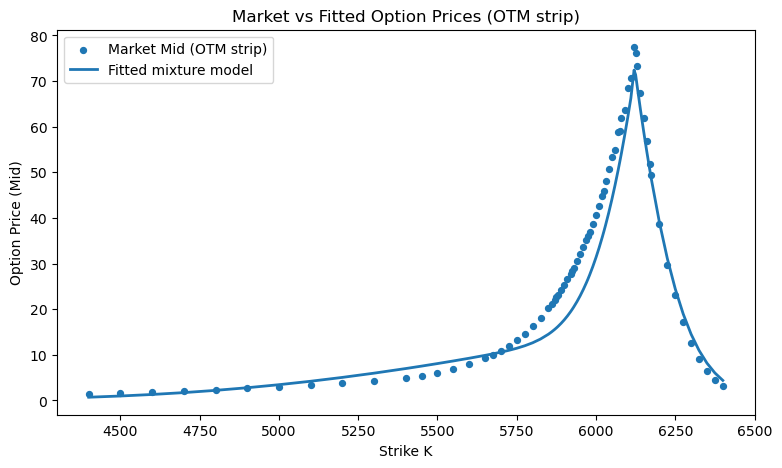

In [24]:
plt.figure(figsize=(9,5))
plt.scatter(K_cal, P_mkt, s=18, label="Market Mid (OTM strip)")
plt.plot(K_cal, P_fit, linewidth=2, label="Fitted mixture model")
plt.xlabel("Strike K")
plt.ylabel("Option Price (Mid)")
plt.title("Market vs Fitted Option Prices (OTM strip)")
plt.legend()
plt.show()

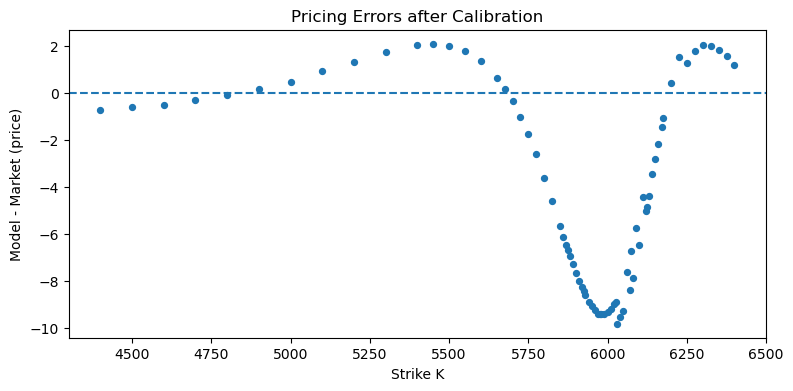

In [25]:
plt.figure(figsize=(9,4))
plt.scatter(K_cal, err, s=18)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Strike K")
plt.ylabel("Model - Market (price)")
plt.title("Pricing Errors after Calibration")
plt.show()